# ============================================
# Traffic Volume Prediction - Modeling Notebook
# ============================================

### Import Libraries

In [11]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib
import shap

import warnings
warnings.filterwarnings("ignore")

from src.data_preprocessing import clean_data
from src.feature_engineering import engineer_features

In [12]:
# Load Data

df = pd.read_csv("../data/Metro_Interstate_Traffic_Volume.csv")

# Clean Data
df = clean_data(df)

# Engineer Features
df = engineer_features(df)

In [13]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,weekday,month,is_weekend,rush_hour,season,temp_c,hour_sin,hour_cos,month_sin,month_cos,is_holiday
0,noholiday,288.28,0.0,0.0,40,clouds,scattered clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,0,1,fall,15.13,7.071068e-01,-0.707107,-0.866025,0.5,0
1,noholiday,289.36,0.0,0.0,75,clouds,broken clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,0,0,fall,16.21,5.000000e-01,-0.866025,-0.866025,0.5,0
2,noholiday,289.58,0.0,0.0,90,clouds,overcast clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,0,0,fall,16.43,2.588190e-01,-0.965926,-0.866025,0.5,0
3,noholiday,290.13,0.0,0.0,90,clouds,overcast clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,0,0,fall,16.98,1.224647e-16,-1.000000,-0.866025,0.5,0
4,noholiday,291.14,0.0,0.0,75,clouds,broken clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,0,0,fall,17.99,-2.588190e-01,-0.965926,-0.866025,0.5,0


In [19]:
initial_split_date = "2017-04-01"

final_split_date = "2018-01-01"

train_df = df[df["date_time"] < initial_split_date]

validation_df = df[(df["date_time"] >= initial_split_date) & (df["date_time"] < final_split_date)]

test_df = df[df["date_time"] >= final_split_date]

train_df.shape, validation_df.shape, test_df.shape

((32237, 21), (7991, 21), (7948, 21))

In [20]:
# REMOVE REDUNDANT COLUMNS

columns_to_drop = [

    "date_time",
    "temp",
    "hour",
    "month"

]

train_df = train_df.drop(columns=columns_to_drop)

validation_df = validation_df.drop(columns=columns_to_drop)

test_df = test_df.drop(columns=columns_to_drop)

train_df.shape, validation_df.shape, test_df.shape

((32237, 17), (7991, 17), (7948, 17))

In [21]:
# FEATURES & TARGET

X_train = train_df.drop(columns=["traffic_volume"])
y_train = train_df["traffic_volume"]

X_val = validation_df.drop(columns=["traffic_volume"])
y_val = validation_df["traffic_volume"]

X_test = test_df.drop(columns=["traffic_volume"])
y_test = test_df["traffic_volume"]

In [22]:
# ONE-HOT ENCODING

X_train = pd.get_dummies(
    X_train,
    drop_first=True
)

X_val = pd.get_dummies(
    X_val,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    drop_first=True
)

In [26]:
# Align columns
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

X_train, X_val = X_train.align(
    X_val,
    join="left",
    axis=1,
    fill_value=0
)

In [27]:
# MODEL TRAINING

# -------------------------
# Linear Regression
# -------------------------

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_val)

In [43]:
# -------------------------
# Random Forest
# -------------------------

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth= 15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_val)

In [44]:
# -------------------------
# XGBoost
# -------------------------

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth= 5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_val)

In [45]:
# EVALUATION FUNCTION

def evaluate_model(y_true, predictions, model_name):

    mae = mean_absolute_error(y_true, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_true, predictions)
    )

    r2 = r2_score(y_true, predictions)

    results = {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    }

    return results

In [46]:
# MODEL EVALUATION

lr_results = evaluate_model(
    y_val,
    lr_predictions,
    "Linear Regression"
)

rf_results = evaluate_model(
    y_val,
    rf_predictions,
    "Random Forest"
)

xgb_results = evaluate_model(
    y_val,
    xgb_predictions,
    "XGBoost"
)

In [47]:
# RESULTS COMPARISON

results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

print("\nModel Performance Comparison\n")

print(results_df)


Model Performance Comparison

               Model     MAE    RMSE  R2 Score
0  Linear Regression  713.72  924.79    0.7833
1      Random Forest  267.29  456.72    0.9471
2            XGBoost  269.64  444.07    0.9500


### Optuna Tuning best model (XGBoost)

In [50]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.001, 5, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 10, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 10, log=True),
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    model.fit(X_train, y_train)

    predictions = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, predictions))

    return rmse

study = optuna.create_study(
    direction="minimize",
    study_name="XGBoost Hyperparameter Optimization"
)

study.optimize(
    objective,
    n_trials=60
)

print("\nBest Hyperparameters\n")

print(study.best_params)

print("\nBest RMSE\n")

print(study.best_value)

[I 2026-05-18 18:13:26,150] A new study created in memory with name: XGBoost Hyperparameter Optimization
[I 2026-05-18 18:13:34,415] Trial 0 finished with value: 448.1767403882089 and parameters: {'n_estimators': 478, 'max_depth': 9, 'learning_rate': 0.02412671295483279, 'subsample': 0.9154124277328876, 'colsample_bytree': 0.8577756604362887, 'min_child_weight': 1, 'gamma': 0.10536896833498391, 'reg_lambda': 1.9294247789525738, 'reg_alpha': 0.567314894095624}. Best is trial 0 with value: 448.1767403882089.
[I 2026-05-18 18:13:36,518] Trial 1 finished with value: 447.3241099862604 and parameters: {'n_estimators': 241, 'max_depth': 4, 'learning_rate': 0.0726092632148578, 'subsample': 0.7941367342455602, 'colsample_bytree': 0.8212640802729992, 'min_child_weight': 6, 'gamma': 4.681862028818194, 'reg_lambda': 0.07678518346657907, 'reg_alpha': 1.0054082330976244}. Best is trial 1 with value: 447.3241099862604.
[I 2026-05-18 18:13:39,883] Trial 2 finished with value: 443.33885883148116 and pa


Best Hyperparameters

{'n_estimators': 273, 'max_depth': 8, 'learning_rate': 0.029397025257873875, 'subsample': 0.8285904986047934, 'colsample_bytree': 0.9978218776937967, 'min_child_weight': 8, 'gamma': 0.0063728180880189365, 'reg_lambda': 8.865314098770519, 'reg_alpha': 0.19486489584621974}

Best RMSE

437.2002901988973


In [52]:
best_params = study.best_params

best_params.update({"random_state": 42, "n_jobs": -1})

xgb_model = XGBRegressor(**best_params)

In [53]:
# Fitting xgboost model with the full training dataset

X_train_full = pd.concat([X_train, X_val], axis=0)

y_train_full = pd.concat([y_train, y_val], axis=0)

xgb_model.fit(X_train_full, y_train_full)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9978218776937967
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegre

In [55]:
# PREDICTIONS

xgb_model_predictions = xgb_model.predict(X_test)

xgb_model_results = evaluate_model(
    y_test,
    xgb_model_predictions,
    "XGBoost"
)

results_df = pd.DataFrame([
    
    xgb_model_results
])


print("\nFinal Model Performance \n")

print(results_df)


Final Model Performance 

     Model     MAE    RMSE  R2 Score
0  XGBoost  262.69  478.28    0.9412


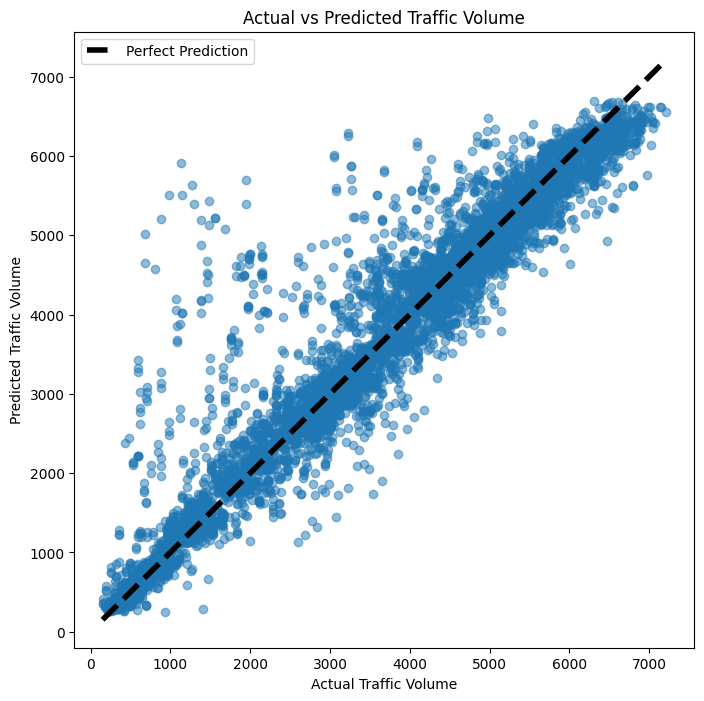

In [67]:
# ACTUAL VS PREDICTED

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    xgb_model_predictions,
    alpha=0.5
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "k--",
    lw=4,
    label="Perfect Prediction"
)

plt.xlabel("Actual Traffic Volume")

plt.ylabel("Predicted Traffic Volume")

plt.title(
    "Actual vs Predicted Traffic Volume"
)

plt.legend(loc="upper left")
plt.savefig(
    "../figures/actual_vs_predicted.png"
)
plt.show()

- Most predictions closely align with the ideal prediction line, indicating strong predictive performance and high agreement between actual and predicted traffic volumes. Nonetheless, prediction dispersion increases slightly at higher traffic volumes, suggesting greater difficulty modeling extreme traffic conditions.

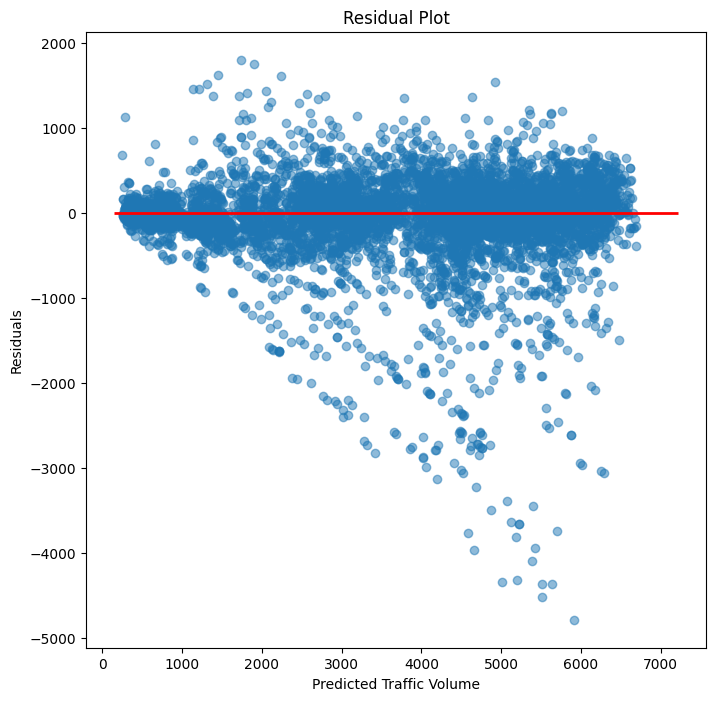

In [66]:
# Residual Plot
# Residual = Actual - Predicted

residuals = y_test - xgb_model_predictions

plt.figure(figsize=(8, 8))

plt.scatter(
    xgb_model_predictions,
    residuals,
    alpha=0.5
)

plt.hlines(
    y=0,
    xmin=y_test.min(),
    xmax=y_test.max(),
    lw=2,
    color="r"
)

plt.xlabel("Predicted Traffic Volume")

plt.ylabel("Residuals")

plt.title(
    "Residual Plot"
)

plt.savefig(
    "../figures/residual_plot.png"
)
plt.show()

- The residual plot indicates that the model predictions are generally unbiased, as residuals are randomly distributed around zero. However, the increasing spread of residuals at higher predicted traffic volumes suggests the presence of heteroscedasticity, indicating reduced prediction consistency under high-traffic conditions.

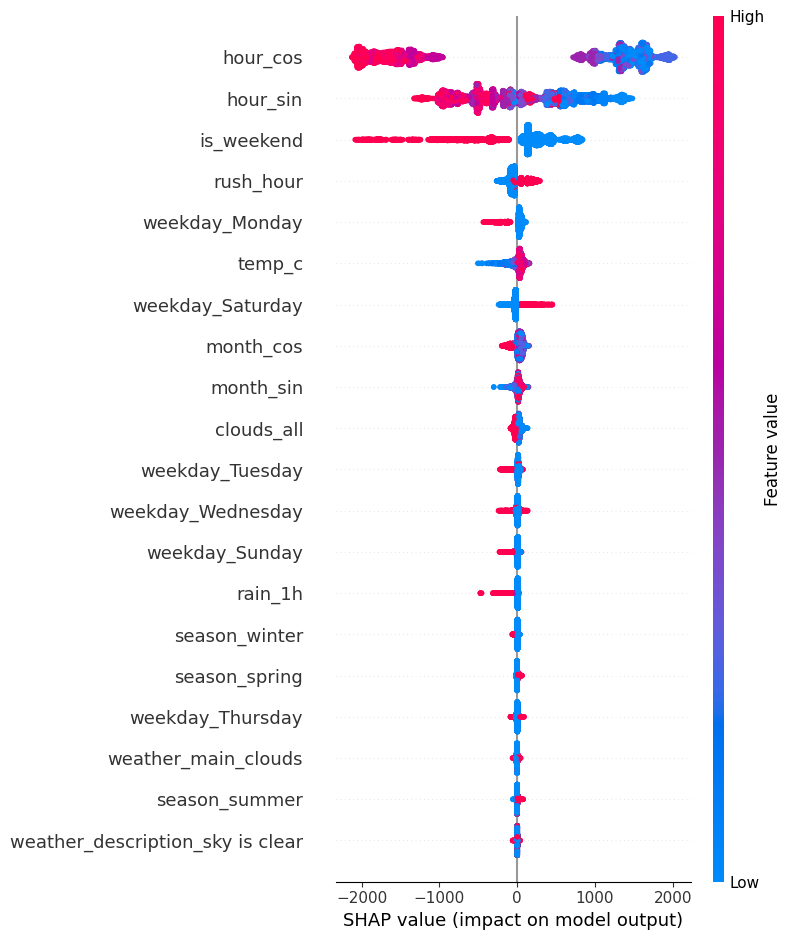

<Figure size 640x480 with 0 Axes>

In [ ]:
# SHAP Interpretation

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="dot", feature_names=X_test.columns)

- SHAP analysis revealed that cyclical hour-based features (hour_cos and hour_sin) exert the strongest influence on traffic predictions, confirming that temporal traffic patterns dominate traffic behavior. Features such as is_weekend and rush_hour also demonstrated meaningful contributions, while weather-related variables showed comparatively weaker influence.

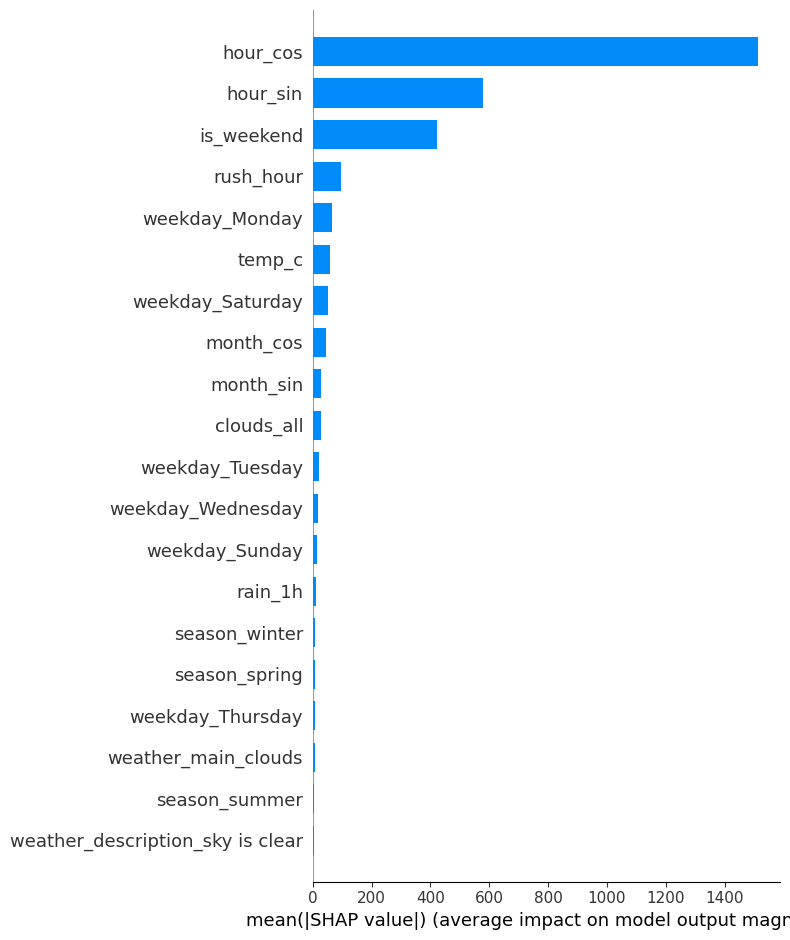

In [60]:
# Feature Importance

shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X_test.columns)

In [61]:
# Saving the model

joblib.dump(xgb_model, "../model/xgb_model.joblib")

['../model/xgb_model.joblib']

In [63]:
# Saving Feature Columns
joblib.dump(X_test.columns.tolist(), "../model/xgb_model_columns.joblib")

['../model/xgb_model_columns.joblib']